<a href="https://colab.research.google.com/github/asegura4488/MecanicaClasica/blob/main/RestriccionParabola_BarraRigida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

¿Convergió? True
q1 = -0.327943
q2 = 1.425422
lambda = -3.356206
m1: (-0.327943, 0.053773)
m2: (1.425422, 1.015913)
longitud varilla = 2.000000


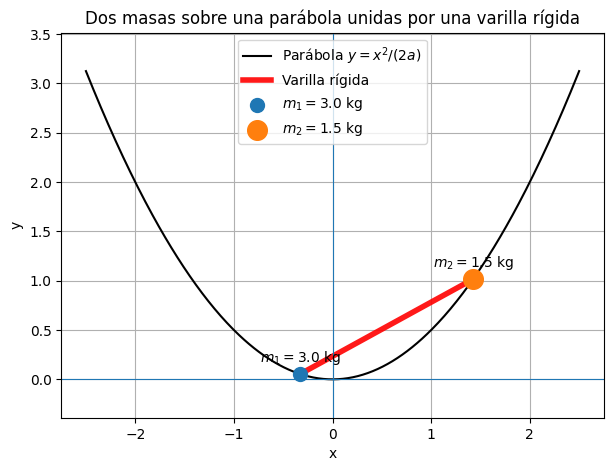

In [10]:
## Ahora con ligadura rigida
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

# Parámetros
a = 1.0
m1 = 3.0
m2 = 1.5
ell = 2.0
g = 9.81

def r(q):
    x = q
    y = q**2 / (2*a)
    return np.array([x, y])

def V(q1, q2):
    y1 = q1**2 / (2*a)
    y2 = q2**2 / (2*a)
    return m1*g*y1 + m2*g*y2

def constraint(q1, q2):
    r1 = r(q1)
    r2 = r(q2)
    return np.dot(r2-r1, r2-r1) - ell**2

def equations(vars):
    q1, q2, lam = vars

    r1 = r(q1)
    r2 = r(q2)

    dr1 = np.array([1, q1/a])
    dr2 = np.array([1, q2/a])

    R = r2 - r1

    # Derivadas de V
    dVdq1 = m1*g*q1/a
    dVdq2 = m2*g*q2/a

    # Derivadas de C = |r2-r1|^2 - ell^2
    dCdq1 = -2 * np.dot(R, dr1)
    dCdq2 =  2 * np.dot(R, dr2)

    eq1 = dVdq1 + lam*dCdq1
    eq2 = dVdq2 + lam*dCdq2
    eq3 = constraint(q1, q2)

    return [eq1, eq2, eq3]

# Solución
guess = [-0.5, 1.0, 1.0]
sol = root(equations, guess)

q1, q2, lam = sol.x

x1, y1 = r(q1)
x2, y2 = r(q2)

print("¿Convergió?", sol.success)
print(f"q1 = {q1:.6f}")
print(f"q2 = {q2:.6f}")
print(f"lambda = {lam:.6f}")
print(f"m1: ({x1:.6f}, {y1:.6f})")
print(f"m2: ({x2:.6f}, {y2:.6f})")
print(f"longitud varilla = {np.linalg.norm(r(q2)-r(q1)):.6f}")

# Gráfica
x = np.linspace(-2.5, 2.5, 400)
y = x**2 / (2*a)

plt.figure(figsize=(7, 5))

plt.plot(x, y, color='k' ,label=r"Parábola $y=x^2/(2a)$")

# Varilla rígida
plt.plot(
    [x1, x2],
    [y1, y2],
    color='r',
    linewidth=4,
    alpha=0.9,
    label="Varilla rígida"
)

plt.scatter([x1], [y1], s=100, zorder=5, label=rf"$m_1={m1}$ kg")
plt.scatter([x2], [y2], s=200, zorder=5, label=rf"$m_2={m2}$ kg")

plt.text(x1, y1 + 0.12, rf"$m_1={m1}$ kg", ha="center")
plt.text(x2, y2 + 0.12, rf"$m_2={m2}$ kg", ha="center")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Dos masas sobre una parábola unidas por una varilla rígida")

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()